# 01 · EDA — RetailRocket

Análisis exploratorio del dataset de eventos de RetailRocket y de las sesiones generadas por `src/data/sessionize.py`. Cubre el **embudo de conversión**, la **distribución de largos de sesión** y el **desbalance de clases** (metodología §M2).

In [1]:
import sys
from pathlib import Path

# Localizar la raíz del repo (marker: SPEC.md) sin depender del cwd.
ROOT = Path.cwd()
while not (ROOT / 'SPEC.md').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EVENTS = ROOT / 'data' / 'raw' / 'retailrocket' / 'events.csv'
SESSIONS = ROOT / 'data' / 'processed' / 'sessions.parquet'

events = pd.read_csv(EVENTS)
sessions = pd.read_parquet(SESSIONS)
print('eventos:', events.shape, '| sesiones:', sessions.shape)

eventos: (2756101, 5) | sesiones: (166957, 10)


## 1. Volumen y tipos de evento

RetailRocket registra tres tipos de evento: `view`, `addtocart` y `transaction`. La compra (`transaction`) es rara y muy desbalanceada.

In [2]:
event_counts = events['event'].value_counts()
print(event_counts)
print('\nvisitantes únicos:', events['visitorid'].nunique())
print('rango temporal:', pd.to_datetime(events['timestamp'].min(), unit='ms'),
      '→', pd.to_datetime(events['timestamp'].max(), unit='ms'))

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

visitantes únicos: 1407580
rango temporal: 2015-05-03 03:00:04.384000 → 2015-09-18 02:59:47.788000


## 2. Embudo de conversión

Visitantes únicos que alcanzan cada etapa. La caída view → addtocart → transaction cuantifica la dificultad del problema de negocio.

view         1,404,179 visitantes
addtocart       37,722 visitantes
transaction     11,719 visitantes

tasa view→cart: 0.0269 | cart→transaction: 0.3107


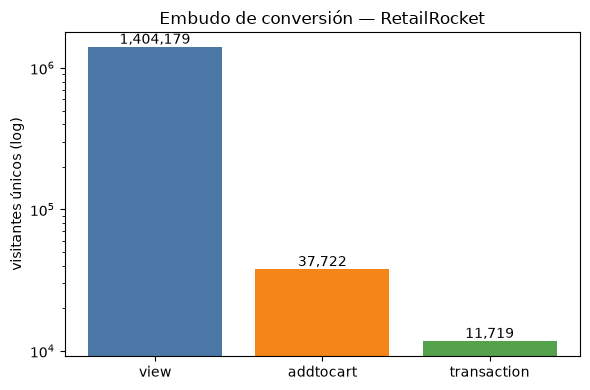

In [3]:
stages = ['view', 'addtocart', 'transaction']
funnel = [events.loc[events['event'] == s, 'visitorid'].nunique() for s in stages]
for s, v in zip(stages, funnel):
    print(f'{s:12s} {v:>9,d} visitantes')
rates = [funnel[i+1] / funnel[i] for i in range(len(funnel)-1)]
print('\ntasa view→cart:', round(rates[0], 4), '| cart→transaction:', round(rates[1], 4))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(stages, funnel, color=['#4C78A8', '#F58518', '#54A24B'])
ax.set_yscale('log')
ax.set_ylabel('visitantes únicos (log)')
ax.set_title('Embudo de conversión — RetailRocket')
for i, v in enumerate(funnel):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

## 3. Distribución de largos de sesión

Tras la sesionización (gap 30 min, filtro <3 eventos, truncado a 50 y anti-leakage), la mayoría de sesiones son cortas.

count    166957.000000
mean          5.212941
std           4.466790
min           3.000000
25%           3.000000
50%           4.000000
75%           5.000000
max          50.000000
Name: length, dtype: float64


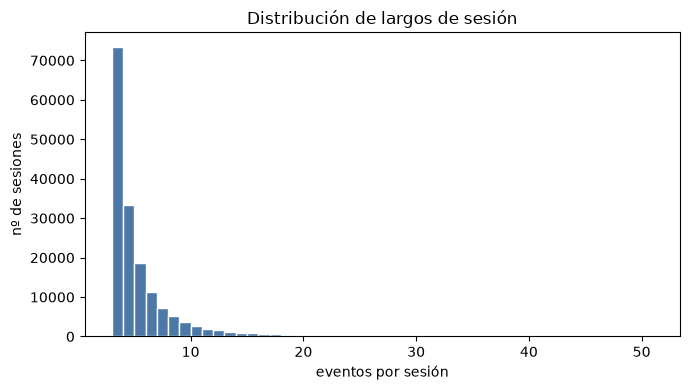

In [4]:
print(sessions['length'].describe())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sessions['length'], bins=range(3, 52), color='#4C78A8', edgecolor='white')
ax.set_xlabel('eventos por sesión'); ax.set_ylabel('nº de sesiones')
ax.set_title('Distribución de largos de sesión')
plt.tight_layout(); plt.show()

## 4. Desbalance de clases

El target `converted` está fuertemente desbalanceado — clave para elegir `class_weight='balanced'`, `pos_weight` en la BCE y evaluar con F1/AUC, no accuracy.

converted
0    159697
1      7260
Name: count, dtype: int64

tasa de conversión: 0.0435  (4.35%)
ratio neg:pos ≈ 22.0 : 1


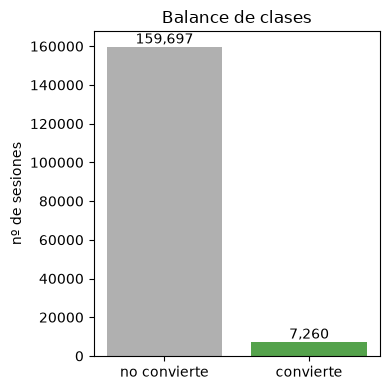

In [5]:
vc = sessions['converted'].value_counts()
rate = sessions['converted'].mean()
print(vc)
print(f'\ntasa de conversión: {rate:.4f}  ({rate*100:.2f}%)')
print(f'ratio neg:pos ≈ {(1-rate)/rate:.1f} : 1')

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(['no convierte', 'convierte'], vc.sort_index().values,
       color=['#B0B0B0', '#54A24B'])
ax.set_ylabel('nº de sesiones'); ax.set_title('Balance de clases')
for i, v in enumerate(vc.sort_index().values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

## 5. Señal temporal

Volumen de sesiones y tasa de conversión por hora del día — útil para el simulador y para la interpretación de negocio.

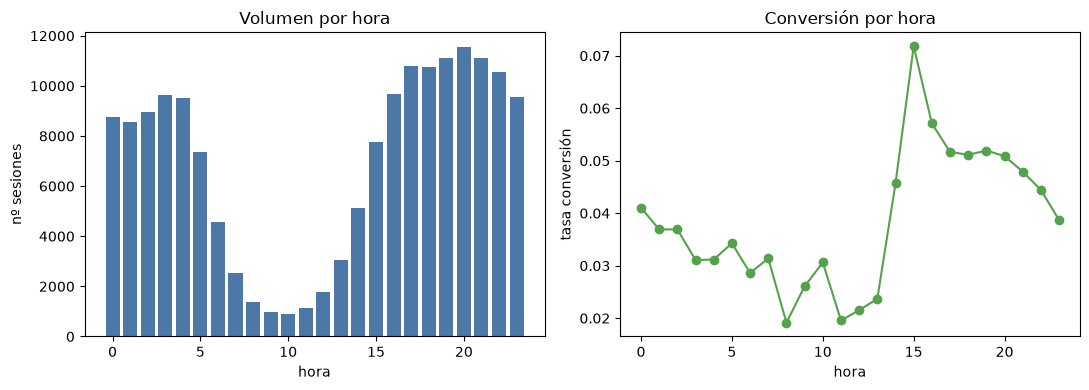

In [6]:
by_hour = sessions.groupby('hour_of_day').agg(
    n=('converted', 'size'), conv=('converted', 'mean'))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.bar(by_hour.index, by_hour['n'], color='#4C78A8')
a1.set_xlabel('hora'); a1.set_ylabel('nº sesiones'); a1.set_title('Volumen por hora')
a2.plot(by_hour.index, by_hour['conv'], marker='o', color='#54A24B')
a2.set_xlabel('hora'); a2.set_ylabel('tasa conversión'); a2.set_title('Conversión por hora')
plt.tight_layout(); plt.show()

## Conclusiones

- Problema fuertemente desbalanceado (~4% de conversión): priorizar F1/AUC.
- Sesiones cortas (mediana ~4 eventos): secuencias breves, modelos pequeños.
- El embudo confirma la caída abrupta hacia la compra → valor de priorizar leads.
- El anti-leakage ya está verificado por `tests/test_sessionize.py`.